In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../logs/memory_dc3.log")

# Remove outliers
df = df[df["memory_MB"] < 4000]

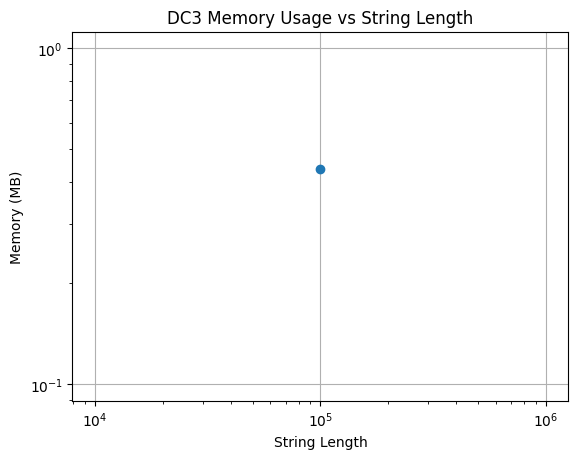

In [3]:
mean_by_len = df.groupby("str_len")["memory_MB"].mean().reset_index()

plt.figure()
plt.plot(mean_by_len["str_len"], mean_by_len["memory_MB"], marker='o')

plt.xlabel("String Length")
plt.ylabel("Memory (MB)")
plt.title("DC3 Memory Usage vs String Length")
plt.grid()

plt.xscale("log")
plt.yscale("log")

plt.show()

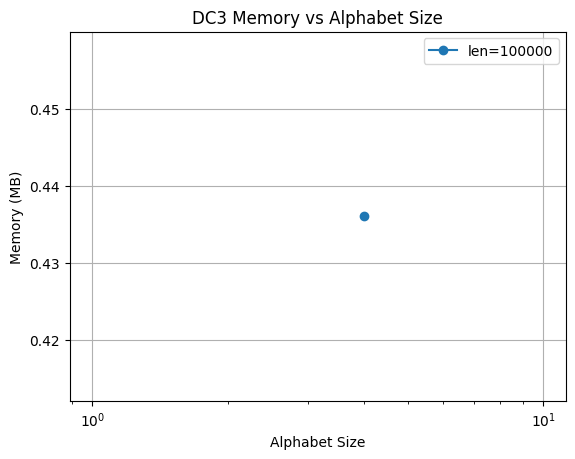

In [4]:
plt.figure()

for length in sorted(df["str_len"].unique()):
    subset = df[df["str_len"] == length]
    
    mean_by_alph = subset.groupby("alph")["memory_MB"].mean().reset_index()
    
    plt.plot(mean_by_alph["alph"], mean_by_alph["memory_MB"],
             marker='o', label=f"len={length}")

    plt.xlabel("Alphabet Size")
    plt.ylabel("Memory (MB)")
    plt.title("DC3 Memory vs Alphabet Size")
    plt.legend()
    plt.grid()

    plt.xscale("log")

    plt.show()